In [ ]:
import random
import numpy as np
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Фиксируем seed для воспроизводимости
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используем устройство: {device}")

Используем устройство: cuda


In [ ]:
dataset = load_dataset("emotion")

print("Размеры датасета:")
print(dataset)

# Посмотрим на классы
print("\nКлассы:", dataset["train"].features["label"].names)

# Примеры
print("\nПримеры текстов:")
for i in range(5):
    print(f"{i+1}. {dataset['train'][i]['text'][:150]}... → {dataset['train'].features['label'].int2str(dataset['train'][i]['label'])}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Размеры датасета:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

Классы: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

Примеры текстов:
1. i didnt feel humiliated... → sadness
2. i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake... → sadness
3. im grabbing a minute to post i feel greedy wrong... → anger
4. i am ever feeling nostalgic about the fireplace i will know that it is still on the property... → love
5. i am feeling grouchy... → anger


In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Пример токенизации
texts = [
    "I am so happy today!",
    "This movie was terrible and boring.",
    "I feel sad and lonely."
]

print("Примеры токенизации:\n")
for text in texts:
    tokens = tokenizer(text, padding=True, truncation=True, max_length=64, return_tensors="pt")
    print(f"Текст: {text}")
    print(f"Токены: {tokenizer.convert_ids_to_tokens(tokens['input_ids'][0])}")
    print(f"input_ids: {tokens['input_ids'][0].tolist()}")
    print(f"attention_mask: {tokens['attention_mask'][0].tolist()}")
    print("-" * 70)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Примеры токенизации:

Текст: I am so happy today!
Токены: ['[CLS]', 'i', 'am', 'so', 'happy', 'today', '!', '[SEP]']
input_ids: [101, 1045, 2572, 2061, 3407, 2651, 999, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1]
----------------------------------------------------------------------
Текст: This movie was terrible and boring.
Токены: ['[CLS]', 'this', 'movie', 'was', 'terrible', 'and', 'boring', '.', '[SEP]']
input_ids: [101, 2023, 3185, 2001, 6659, 1998, 11771, 1012, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1]
----------------------------------------------------------------------
Текст: I feel sad and lonely.
Токены: ['[CLS]', 'i', 'feel', 'sad', 'and', 'lonely', '.', '[SEP]']
input_ids: [101, 1045, 2514, 6517, 1998, 9479, 1012, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1]
----------------------------------------------------------------------


In [ ]:
model_name = "bert-base-uncased"
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=6).to(device)

# Простой инференс
print("Инференс предобученной модели (случайные веса классификатора):\n")

for i in range(5):
    text = dataset["test"][i]["text"]
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        pred = torch.argmax(outputs.logits, dim=1).item()

    true_label = dataset["test"].features["label"].int2str(dataset["test"][i]["label"])
    pred_label = dataset["test"].features["label"].int2str(pred)

    print(f"Текст: {text[:120]}...")
    print(f"Истинно: {true_label} | Предсказано: {pred_label}\n")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Инференс предобученной модели (случайные веса классификатора):

Текст: im feeling rather rotten so im not very ambitious right now...
Истинно: sadness | Предсказано: anger

Текст: im updating my blog because i feel shitty...
Истинно: sadness | Предсказано: anger

Текст: i never make her separate from me because i don t ever want her to feel like i m ashamed with her...
Истинно: sadness | Предсказано: joy

Текст: i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived...
Истинно: joy | Предсказано: anger

Текст: i was feeling a little vain when i did this one...
Истинно: sadness | Предсказано: anger



In [ ]:
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_datasets = dataset.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=6).to(device)

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",           # современное название
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    seed=42,
    report_to="none",
    logging_steps=50,
)

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="macro")
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
    # tokenizer больше не передаётся в Trainer (убрали)
)

print("Начинаем обучение...")
trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Начинаем обучение...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.203034,0.194457,0.927500,0.904030
2,0.112263,0.150508,0.936500,0.907252
3,0.081565,0.166448,0.942500,0.916878


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=3000, training_loss=0.20167938454945883, metrics={'train_runtime': 1290.9676, 'train_samples_per_second': 37.181, 'train_steps_per_second': 2.324, 'total_flos': 3157446057984000.0, 'train_loss': 0.20167938454945883, 'epoch': 3.0})

In [ ]:
test_results = trainer.evaluate(tokenized_datasets["test"])
print("Результаты на test:")
print(f"Accuracy:  {test_results['eval_accuracy']:.4f}")
print(f"F1-macro:  {test_results['eval_f1']:.4f}")

Результаты на test:
Accuracy:  0.9280
F1-macro:  0.8779


In [ ]:
import os
os.makedirs('artifacts/figures', exist_ok=True)


Сохранено 100 примеров в sample_predictions.csv


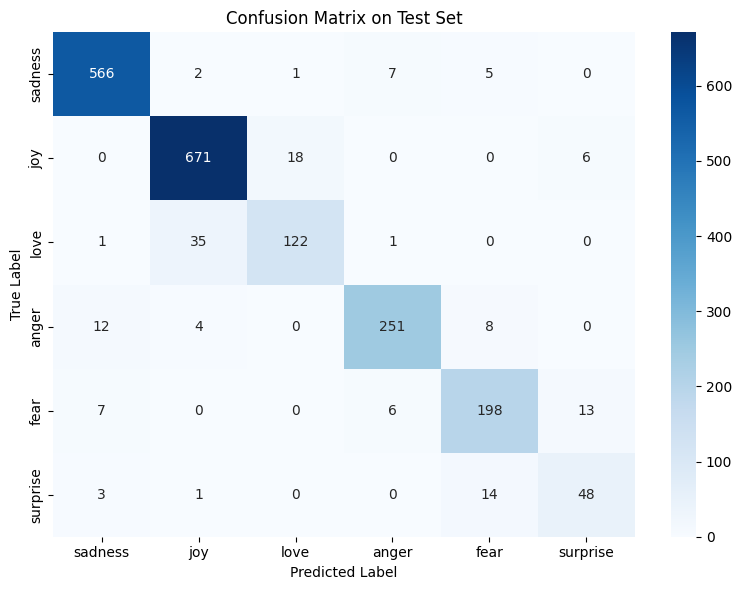

Артефакты успешно сохранены!
Accuracy на test: 0.9280
F1-macro на test: 0.8779


In [ ]:
predictions_output = trainer.predict(tokenized_datasets["test"])
pred_labels = np.argmax(predictions_output.predictions, axis=1)
true_labels = predictions_output.label_ids

# Преобразуем метки в названия классов (исправленный вариант)
label_feature = dataset["train"].features["label"]
class_names = label_feature.names

# Надёжное преобразование в строки
true_label_names = [class_names[int(label)] for label in true_labels[:100]]
pred_label_names = [class_names[int(label)] for label in pred_labels[:100]]

# Создаём DataFrame
df = pd.DataFrame({
    "text": dataset["test"]["text"][:100],
    "true_label": true_label_names,
    "pred_label": pred_label_names
})

# Сохраняем
df.to_csv("artifacts/sample_predictions.csv", index=False)
print(f"Сохранено {len(df)} примеров в sample_predictions.csv")

cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Set')
plt.tight_layout()
plt.savefig("artifacts/confusion_matrix.png")
plt.show()

print("Артефакты успешно сохранены!")
print(f"Accuracy на test: {accuracy_score(true_labels, pred_labels):.4f}")
print(f"F1-macro на test: {f1_score(true_labels, pred_labels, average='macro'):.4f}")